<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Загрузка-данных" data-toc-modified-id="Загрузка-данных-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Загрузка данных</a></span><ul class="toc-item"><li><span><a href="#Подключим-функции-и-библиотеки,-зададим-параметры-отображения" data-toc-modified-id="Подключим-функции-и-библиотеки,-зададим-параметры-отображения-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Подключим функции и библиотеки, зададим параметры отображения</a></span></li><li><span><a href="#Проверка-данных" data-toc-modified-id="Проверка-данных-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Проверка данных</a></span></li></ul></li><li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Предобработка данных</a></span></li><li><span><a href="#Исследовательский-анализ-данных" data-toc-modified-id="Исследовательский-анализ-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Исследовательский анализ данных</a></span><ul class="toc-item"><li><span><a href="#Исследование-main_data." data-toc-modified-id="Исследование-main_data.-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Исследование <code>main_data</code>.</a></span></li><li><span><a href="#Исследование-cow_data." data-toc-modified-id="Исследование-cow_data.-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Исследование <code>cow_data</code>.</a></span></li><li><span><a href="#Исследование-dad_data" data-toc-modified-id="Исследование-dad_data-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Исследование <code>dad_data</code></a></span></li></ul></li><li><span><a href="#Корреляционный-анализ" data-toc-modified-id="Корреляционный-анализ-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Корреляционный анализ</a></span></li><li><span><a href="#Обучение-модели-линейной-регрессии" data-toc-modified-id="Обучение-модели-линейной-регрессии-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Обучение модели линейной регрессии</a></span></li><li><span><a href="#Обучение-модели-логистической-регрессии" data-toc-modified-id="Обучение-модели-логистической-регрессии-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Обучение модели логистической регрессии</a></span></li><li><span><a href="#Итоговые-выводы" data-toc-modified-id="Итоговые-выводы-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Итоговые выводы</a></span></li></ul></div>

# Отбор коров для фермы.

К нам обратился фермер, владелец молочного хозяйства «Вольный луг». Он хочет купить бурёнок, чтобы расширить поголовье стада коров. Для этого он заключил выгодный контракт с ассоциацией пастбищ «ЭкоФерма».  

Фермер хочет, чтобы каждая бурёнка давала не менее 6000 килограммов молока в год, а её надой был вкусным — строго по его критериям, ничуть не хуже.  

Поэтому нам нужно разработать модель машинного обучения, которая поможет ему управлять рисками и принимать объективное решение о покупке. «ЭкоФерма» готова предоставить подробные данные о своих коровах. Нам нужно создать две прогнозные модели для отбора бурёнок в поголовье:  
- Первая будет прогнозировать возможный удой коровы (целевой признак Удой)  
- Вторая — рассчитывать вероятность получить вкусное молоко от коровы (целевой признак Вкус молока).  

С помощью модели нужно отобрать коров по двум критериям:  
- Средний удой за год — не менее 6000 килограммов;
- Молоко должно быть вкусным.

**Описание данных:**  
1. **`ferma_main.csv` содержит данные о стаде фермера на текущий момент:**  
    - `id` — уникальный идентификатор коровы.  
    - `Удой, кг` — масса молока, которую корова даёт в год (в килограммах).
    - `ЭКЕ (Энергетическая кормовая единица)` — показатель питательности корма коровы.
    - `Сырой протеин, г` — содержание сырого протеина в корме (в граммах).
    - `СПО (Сахаро-протеиновое соотношение)` — отношение сахара к протеину в корме коровы.
    - `Порода` — порода коровы.
    - `Тип пастбища` — ландшафт лугов, на которых паслась корова.
    - `порода папы_быка` — порода папы коровы.
    - `Жирность,%` — содержание жиров в молоке (в процентах).
    - `Белок,%` — содержание белков в молоке (в процентах).
    - `Вкус молока` — оценка вкуса по личным критериям фермера, бинарный признак (вкусно, не вкусно).
    - `Возраст` — возраст коровы, бинарный признак (менее_2_лет, более_2_лет).  
    
    Признаки в датасете ferma_main.csv можно разделить на группы: 
        - Характеристики коровы: `id, Порода, порода папы_быка, Возраст.`
        - Характеристики корма: `ЭКЕ (Энергетическая кормовая единица), Сырой протеин, г, СПО (Сахаро-протеиновое соотношение)`.
        - Характеристика пастбища: `Тип пастбища`.
        - Характеристики молока: `Удой, кг, Жирность,%, Белок,%, Вкус молока`.  
        
        
2. **Файл `ferma_dad.csv` хранит имя папы каждой коровы в стаде фермера:**  
    - `id` — уникальный идентификатор коровы.
    - `Имя Папы` — имя папы коровы.
    
    
3. **Файл cow_buy.csv — это данные о коровах «ЭкоФермы», которых фермер хочет изучить перед покупкой:**  
    - `Порода` — порода коровы.
    - `Тип пастбища` — ландшафт лугов, на которых паслась корова.
    - `порода папы_быка` — порода папы коровы.
    - `Имя_папы` — имя папы коровы.
    - `Текущая_жирность,%` — содержание жиров в молоке (в процентах).
    - `Текущий_уровень_белок,%` — содержание белков в молоке (в процентах).
    - `Возраст — возраст коровы`, бинарный признак (менее_2_лет, более_2_лет).

**План работы:**  
Нужно написать план работы

## Загрузка данных

### Подключим функции и библиотеки, зададим параметры отображения

Подключим библиотеки:

In [649]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 

In [650]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score

Зададим параметры отображения:

In [651]:
pd.set_option('display.max_columns', None) #установим параметр отображения, чтобы показывать все столбцы в датафрейме при выводе.
pd.set_option('display.float_format', '{:,.2f}'.format) #избавимся от экспоненциальных форм для удобства

Подключим датафреймы:

In [652]:
try:
    main_data = pd.read_csv('/datasets/ferma_main.csv', decimal=',', sep=';')
    dad_data = pd.read_csv('/datasets/ferma_dad.csv', decimal=',', sep=';')
    cow_data = pd.read_csv('/datasets/cow_buy.csv', decimal=',', sep=';')
except:
    main_data = pd.read_csv('https://code.s3.yandex.net/datasets/ferma_main.csv', decimal=',', sep=';')
    dad_data = pd.read_csv('https://code.s3.yandex.net/datasets/ferma_dad.csv', decimal=',', sep=';')
    cow_data = pd.read_csv('https://code.s3.yandex.net/datasets/cow_buy.csv', decimal=',', sep=';')

Создадим функции для дальнейшей удобной работы:

In [653]:
#функция для вывода пропусков и дубликатов в количественном и процентном виде
def mis_dup_info(df):
    missing_values = df.isnull().sum() # количество пропущеннных строк
    duplicated_values = df.duplicated().sum() #Количество явных дубликатов
    total_values = df.shape[0]  # общее количество строк

    # добавление процента значений
    missing_percent = ((missing_values / total_values) * 100).round(1).astype(str) + '%'
    duplicated_percent = ((duplicated_values / total_values) * 100).round(1).astype(str) + '%'
    
    # создание датафреймов отображающих нужные данные
    missing_duplicated_df = pd.DataFrame({
        'total' : total_values,
        'missing': missing_values,
        'percent_missing': missing_percent,
        'duplicated' : duplicated_values,
        'percent_duplicated' : duplicated_percent
        
    })   
    

    return missing_duplicated_df

In [654]:
#вывод основной информации о датафрейме
def data_info(df):
    display('Первые строки')
    display(df.head())
    display('Описание данных')
    display(df.describe().T)
    display('Базовая системная информация')
    display(df.info())

Сделаем функции для построение графиков.

In [ ]:
#информация и графики количественных данных
def kol_info(x, x_title, y_title, title, color='#3498DB', bins=100, figsize=(11,6), alpha=1):
    print(x.describe())
    x.hist(
        color=color,
        bins=bins,
        figsize=figsize,
        alpha=alpha
    )
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(title)
    plt.show()
    
    plt.boxplot(x, vert=False)
    plt.title(title)
    plt.figure(figsize=(15, 6))
    plt.show()

In [ ]:
#информация и графики категориальных данных
def cat_info(x, x_title, y_title, title, color='#3498DB', figsize=(11,4), alpha=1):
    tmp = x.copy()
    
    x_val = x.value_counts(ascending=True)
    
    #горизонтальная диаграмма
    ax = x_val.plot(
        kind='barh',
        figsize=figsize,
        color=color,
        alpha=alpha
    )
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(title)
    
    #добавление значения рядом со столбцовм
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')
    plt.show()
    
    #круговая диаграмма
    x_val.plot(kind='pie', figsize=figsize)
    x_val.plot(
        kind='pie',
        title=title,
        autopct= "%.0f%%",
        )
    plt.show()

### Проверка данных

Изучим данные, при необходимости переименуем столбцы.

In [657]:
data_info(main_data) #датафрейм main_data

'Первые строки'

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,14.20,1743,0.89,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.08,вкусно,более_2_лет
1,2,5529,12.80,2138,0.89,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.08,вкусно,менее_2_лет
2,3,5810,14.00,1854,0.89,РефлешнСоверинг,Холмистое,Соверин,3.59,3.07,не вкусно,более_2_лет
3,4,5895,12.40,2012,0.89,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.08,не вкусно,более_2_лет
4,5,5302,12.80,1675,0.89,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.07,вкусно,менее_2_лет


'Описание данных'

,count,mean,std,min,25%,50%,75%,max
id,634.00,317.46,183.10,1.00,159.25,317.50,475.75,629.00
"Удой, кг",634.00,"6,187.03","1,638.40","5,204.00","5,751.75","6,130.50","6,501.00","45,616.00"
ЭКЕ (Энергетическая кормовая единица),634.00,14.54,1.30,10.90,13.50,14.70,15.60,16.80
"Сырой протеин, г",634.00,"1,922.68",182.39,"1,660.00","1,772.25","1,880.50","2,058.75","2,349.00"
СПО (Сахаро-протеиновое соотношение),634.00,0.91,0.03,0.84,0.89,0.93,0.94,0.96
"Жирность,%",634.00,3.60,0.17,2.99,3.59,3.65,3.72,3.75
"Белок,%",634.00,3.08,0.00,3.07,3.07,3.08,3.08,3.08


'Базовая системная информация'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     634 non-null    int64  
 1   Удой, кг                               634 non-null    int64  
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    float64
 3   Сырой протеин, г                       634 non-null    int64  
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    float64
 5   Порода                                 634 non-null    object 
 6   Тип пастбища                           634 non-null    object 
 7   порода папы_быка                       634 non-null    object 
 8   Жирность,%                             634 non-null    float64
 9   Белок,%                                634 non-null    float64
 10  Вкус молока                            634 non-null    object 
 11  Возрас

None

dataframe имеет 634 строки.

Приведем series в dataframe к единному, удобному формату, переименуем столбцы.

In [658]:
main_data.rename(columns={
    'Удой, кг':'удой',
    'ЭКЕ (Энергетическая кормовая единица)':'эке',
    'Сырой протеин, г':'сырой_протеин',
    'СПО (Сахаро-протеиновое соотношение)':'спо',
    'Порода':'порода',
    'Тип пастбища':'тип_пастбища',
    'порода папы_быка':'порода_папы',
    'Жирность,%':'жирность',
    'Белок,%':'белок',
    'Вкус молока':'вкус_молока',
    'Возраст':'возраст'
}, inplace=True)

Сделаем то же самое с остальными dataframe.

In [659]:
data_info(cow_data) #датафрейм cow_data

'Первые строки'

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.08,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.08,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.07,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.06,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.07,более_2_лет


'Описание данных'

,count,mean,std,min,25%,50%,75%,max
"Текущая_жирность,%",20.00,3.58,0.13,3.34,3.51,3.59,3.65,3.77
"Текущий_уровень_белок,%",20.00,3.07,0.01,3.05,3.06,3.07,3.08,3.08


'Базовая системная информация'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Порода                   20 non-null     object 
 1   Тип пастбища             20 non-null     object 
 2   порода папы_быка         20 non-null     object 
 3   Имя_папы                 20 non-null     object 
 4   Текущая_жирность,%       20 non-null     float64
 5   Текущий_уровень_белок,%  20 non-null     float64
 6   Возраст                  20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


None

dataframe имеет 20 строк, подкорректируем название столбцов.

In [660]:
cow_data.rename(columns={
    'Порода':'порода',
    'Тип пастбища':'тип_пастбища',
    'порода папы_быка':'порода_папы',
    'Имя_папы':'имя_папы',
    'Текущая_жирность,%':'жирность',
    'Текущий_уровень_белок,%':'белок',
    'Возраст':'возраст'
}, inplace=True)

In [661]:
data_info(dad_data)

'Первые строки'

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


'Описание данных'

,count,mean,std,min,25%,50%,75%,max
id,629.00,315.00,181.72,1.00,158.00,315.00,472.00,629.00


'Базовая системная информация'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


None

In [662]:
dad_data.rename(columns={'Имя Папы':'имя_папы'}, inplace=True)

dataframe имеет 629 строк.

**Вывод:**  
Мы привели все столбцы к одному стилю, подключили библиотеки и функции, и поняли что данные загрузились, и отображаются корректно.

##  Предобработка данных

Проверим данные на наличие пропусков и дубликатов.  
Для этого используем функцию.  

In [663]:
print('main_data:')
mis_dup_info(main_data)

main_data:


,total,missing,percent_missing,duplicated,percent_duplicated
id,634,0,0.0%,5,0.8%
удой,634,0,0.0%,5,0.8%
эке,634,0,0.0%,5,0.8%
сырой_протеин,634,0,0.0%,5,0.8%
спо,634,0,0.0%,5,0.8%
порода,634,0,0.0%,5,0.8%
тип_пастбища,634,0,0.0%,5,0.8%
порода_папы,634,0,0.0%,5,0.8%
жирность,634,0,0.0%,5,0.8%
белок,634,0,0.0%,5,0.8%


In [664]:
print('dad_data:')
mis_dup_info(dad_data)

dad_data:


,total,missing,percent_missing,duplicated,percent_duplicated
id,629,0,0.0%,0,0.0%
имя_папы,629,0,0.0%,0,0.0%


In [665]:
print('cow_data:')
mis_dup_info(cow_data)

cow_data:


,total,missing,percent_missing,duplicated,percent_duplicated
порода,20,0,0.0%,4,20.0%
тип_пастбища,20,0,0.0%,4,20.0%
порода_папы,20,0,0.0%,4,20.0%
имя_папы,20,0,0.0%,4,20.0%
жирность,20,0,0.0%,4,20.0%
белок,20,0,0.0%,4,20.0%
возраст,20,0,0.0%,4,20.0%


Пропусков нет, есть явные дубликаты, избавимся от них.

In [666]:
main_data = main_data.drop_duplicates().reset_index(drop=True)
cow_data = cow_data.drop_duplicates().reset_index(drop=True)

Проверим неявные дубликаты. Пройдемся по всем категориальным данным.

In [667]:
#main_data
print(f"Порода{main_data['порода'].unique()}")
print(f"Тип пастбища{main_data['тип_пастбища'].unique()}")
print(f"Порода папы{main_data['порода_папы'].unique()}")
print(f"Вкус молока{main_data['вкус_молока'].unique()}")
print(f"Возраст{main_data['возраст'].unique()}")

Порода['Вис Бик Айдиал' 'РефлешнСоверинг']
Тип пастбища['Равнинное' 'Равнинные' 'Холмистое']
Порода папы['Айдиал' 'Соверин' 'Айдиалл']
Вкус молока['вкусно' 'не вкусно']
Возраст['более_2_лет' 'менее_2_лет']


Видны дубликаты в столбцах `тип_пастбища` и `порода_папы`.  
Устраним неявные дубликаты, переименуем строки.

In [668]:
main_data['тип_пастбища'].replace('Равнинные', 'Равнинное', inplace=True)
main_data['порода_папы'].replace('Айдиалл', 'Айдиал', inplace=True)

In [669]:
#dad_data
print(f"Имя папы{dad_data['имя_папы'].unique()}")

Имя папы['Буйный' 'Соловчик' 'Барин' 'Геркулес']


In [670]:
#cow_data
print(f"Порода{cow_data['порода'].unique()}")
print(f"Тип пастбища{cow_data['тип_пастбища'].unique()}")
print(f"Порода папы{cow_data['порода_папы'].unique()}")
print(f"Имя папы{cow_data['имя_папы'].unique()}")

Порода['Вис Бик Айдиал' 'РефлешнСоверинг']
Тип пастбища['холмистое' 'равнинное']
Порода папы['Айдиал' 'Соверин']
Имя папы['Геркулес' 'Буйный' 'Барин' 'Соловчик']


Все дубликаты обработаны.  
Типы данных у всех столбцов указаны правильно.

**Вывод:**  
Были выявлены и обработаны явные и неявные дубликаты. Данные готовы к дальнейшему анализу.

## Исследовательский анализ данных

В этом разделе мы проведем анализ всех признаков, построем для них диаграммы, и сделаем выводы. При необходимости удалим выбросы.

### Исследование `main_data`.

Выведем основную информацию.

In [671]:
data_info(main_data)
main_data.shape

'Первые строки'

,id,удой,эке,сырой_протеин,спо,порода,тип_пастбища,порода_папы,жирность,белок,вкус_молока,возраст
0,1,5863,14.20,1743,0.89,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.08,вкусно,более_2_лет
1,2,5529,12.80,2138,0.89,Вис Бик Айдиал,Равнинное,Соверин,3.54,3.08,вкусно,менее_2_лет
2,3,5810,14.00,1854,0.89,РефлешнСоверинг,Холмистое,Соверин,3.59,3.07,не вкусно,более_2_лет
3,4,5895,12.40,2012,0.89,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.08,не вкусно,более_2_лет
4,5,5302,12.80,1675,0.89,Вис Бик Айдиал,Равнинное,Соверин,3.73,3.07,вкусно,менее_2_лет


'Описание данных'

,count,mean,std,min,25%,50%,75%,max
id,629.00,315.00,181.72,1.00,158.00,315.00,472.00,629.00
удой,629.00,"6,188.75","1,644.80","5,204.00","5,751.00","6,133.00","6,501.00","45,616.00"
эке,629.00,14.54,1.31,10.90,13.50,14.70,15.60,16.80
сырой_протеин,629.00,"1,923.36",182.96,"1,660.00","1,771.00","1,888.00","2,062.00","2,349.00"
спо,629.00,0.91,0.03,0.84,0.89,0.93,0.94,0.96
жирность,629.00,3.60,0.17,2.99,3.59,3.65,3.72,3.75
белок,629.00,3.08,0.00,3.07,3.07,3.08,3.08,3.08


'Базовая системная информация'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             629 non-null    int64  
 1   удой           629 non-null    int64  
 2   эке            629 non-null    float64
 3   сырой_протеин  629 non-null    int64  
 4   спо            629 non-null    float64
 5   порода         629 non-null    object 
 6   тип_пастбища   629 non-null    object 
 7   порода_папы    629 non-null    object 
 8   жирность       629 non-null    float64
 9   белок          629 non-null    float64
 10  вкус_молока    629 non-null    object 
 11  возраст        629 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 59.1+ KB


None

(629, 12)

Датафрейм имеет 629 строк, и 12 столбцов, разберем их по столбцам.

Начнем с количественных данных.

**Столбец `удой`.**   

count      629.00
mean     6,188.75
std      1,644.80
min      5,204.00
25%      5,751.00
50%      6,133.00
75%      6,501.00
max     45,616.00
Name: удой, dtype: float64


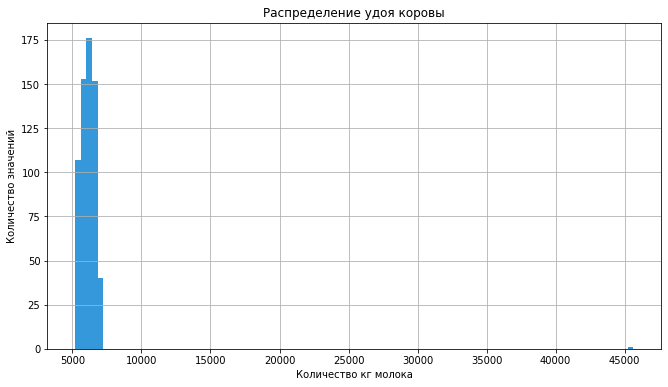

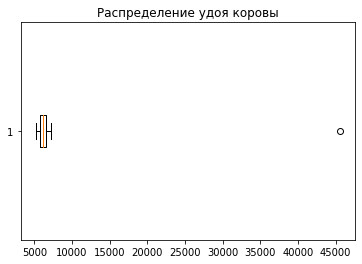

<Figure size 1080x432 with 0 Axes>

In [672]:
kol_info(main_data['удой'], 'Количество кг молока', 'Количество значений', 'Распределение удоя коровы')

Виден сильный выброс, рассмотрим его

In [673]:
main_data['удой'].sort_values().tail()

294     7197
296     7201
135     7207
70      7222
16     45616
Name: удой, dtype: int64

Так как он всего один, мы можем без проблем избавиться от него.

In [674]:
main_data = main_data[main_data['удой'] <= 10000]
main_data['удой'].sort_values().count()

628

count     628.00
mean    6,125.97
std       475.86
min     5,204.00
25%     5,749.75
50%     6,132.50
75%     6,501.00
max     7,222.00
Name: удой, dtype: float64


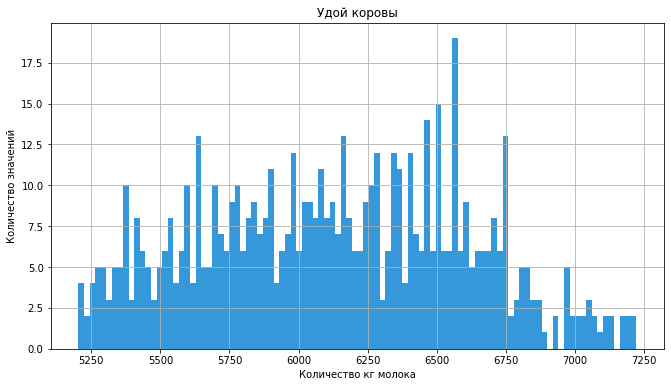

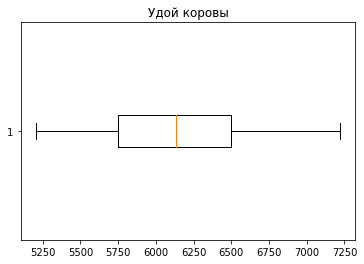

<Figure size 1080x432 with 0 Axes>

In [675]:
kol_info(main_data['удой'], 'Количество кг молока', 'Количество значений', 'Удой коровы')

Количество кг молока распредело достаточно ровно по плоскости, видно снижение количества после одного из пиков на значении около 6750 литров. Наблюдается большой пик на значении примерно 6550. Ящик с усами полностью покрывает все значения строк.

 Проведите статистический анализ всех признаков.
Постройте графики для каждого признака. Помните, что количественным и категориальным признакам подходят разные графики.
Сделайте выводы о данных:
напишите, заметили ли вы выбросы, необычное распределение количественных признаков или другие особенности;
расскажите, как вы планируете улучшить данные.


**Столбец `эке`**

count   628.00
mean     14.55
std       1.30
min      10.90
25%      13.50
50%      14.70
75%      15.60
max      16.80
Name: эке, dtype: float64


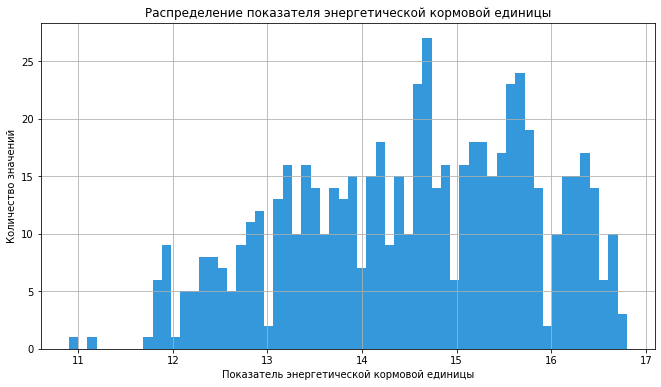

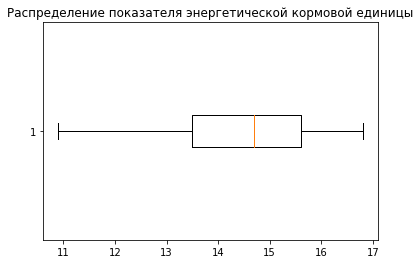

<Figure size 1080x432 with 0 Axes>

In [676]:
kol_info(main_data['эке'], 'Показатель энергетической кормовой единицы',
         'Количество значений',
         'Распределение показателя энергетической кормовой единицы', bins=60)

Выбросов нет, данные плавно распределены со значений 11.7 по 16.5 за исключением пиков на значении ~14.7 и ~15.7. Так же есть несколько не сильно отстающих значений.

**Столбец `сырой_протеин`.**

count     628.00
mean    1,923.76
std       182.83
min     1,660.00
25%     1,771.75
50%     1,888.00
75%     2,062.25
max     2,349.00
Name: сырой_протеин, dtype: float64


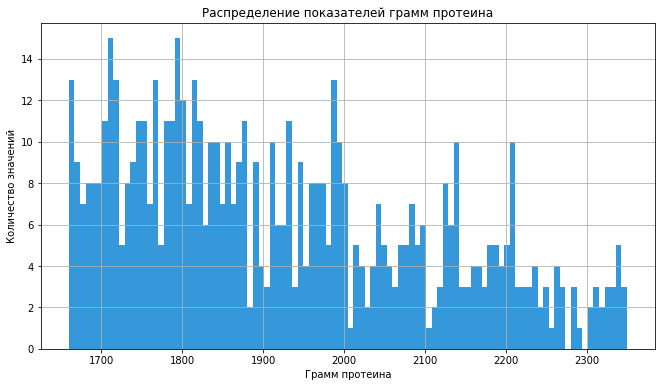

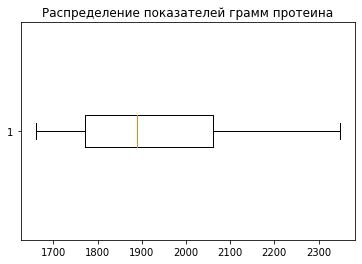

<Figure size 1080x432 with 0 Axes>

In [677]:
kol_info(main_data['сырой_протеин'], 'Грамм протеина',
         'Количество значений',
         'Распределение показателей грамм протеина')

Выбросов нет, данные плавно распределены до значения 2000 дальше количества грамм меньше. есть два пика на значениях 1710 и 1790.

**Столбец `спо`.**

count   628.00
mean      0.91
std       0.03
min       0.84
25%       0.89
50%       0.93
75%       0.94
max       0.96
Name: спо, dtype: float64


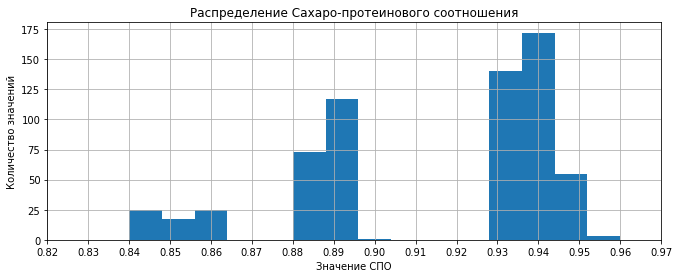

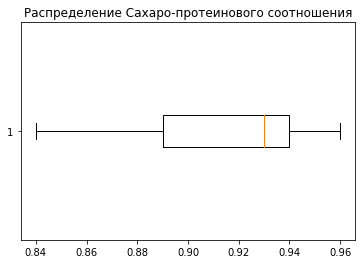

In [678]:
print(main_data['спо'].describe())
main_data['спо'].hist(figsize=(11,4), bins=15)
plt.xticks(np.arange(0.82, 0.97, 0.01))
plt.xlabel('Значение СПО')
plt.ylabel('Количество значений')
plt.title('Распределение Сахаро-протеинового соотношения')
plt.show()

plt.boxplot(main_data['спо'], vert=False)
plt.title('Распределение Сахаро-протеинового соотношения')
plt.show()

Выбросов нет, Наблюдается три промежутка со значениями, пик приходится на 0.94.

**Столбец `жирность`**.

count   628.00
mean      3.60
std       0.17
min       2.99
25%       3.59
50%       3.65
75%       3.72
max       3.75
Name: жирность, dtype: float64


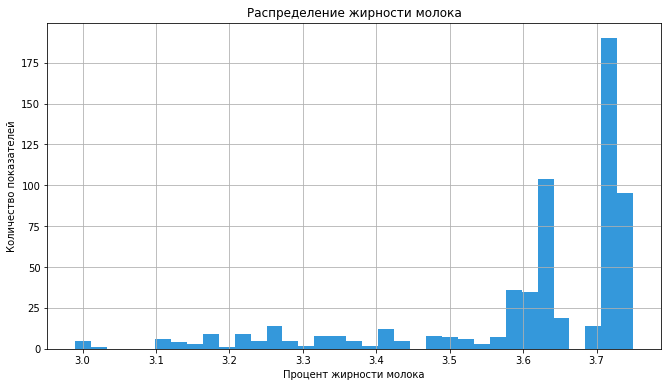

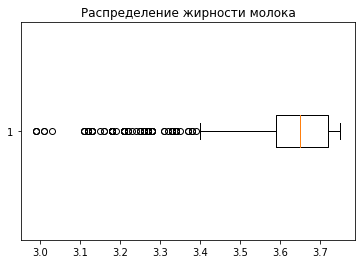

<Figure size 1080x432 with 0 Axes>

In [679]:
kol_info(main_data['жирность'],
         'Процент жирности молока',
         'Количество показателей',
         'Распределение жирности молока', bins=35)

Наблюдается большое количество выбросов, но значения на выбросах вполне правдивые, корова может дать молоко трехпроцентной жирности, стоит учитывать эти данные, потому заменять значения не стоит. Выраженный пик виднеется на значении 3.7, есть так же пик поменьше на значении 3.6.

count   628.00
mean      3.08
std       0.00
min       3.07
25%       3.07
50%       3.08
75%       3.08
max       3.08
Name: белок, dtype: float64


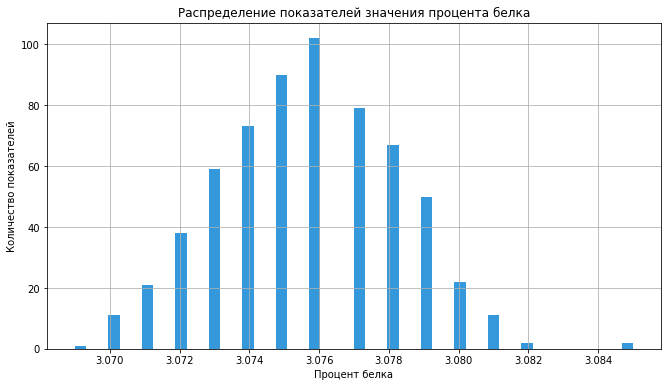

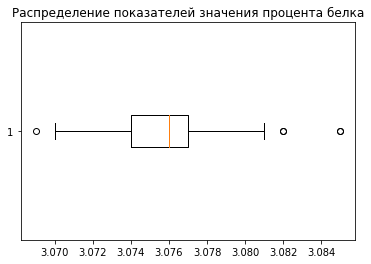

<Figure size 1080x432 with 0 Axes>

In [680]:
kol_info(main_data['белок'],
         'Процент белка',
         'Количество показателей',
         'Распределение показателей значения процента белка', bins=50)

На графике изображено нормальное распределение с пиком на значении 3.076, есть небольшие выбросы, не сильно отличающиеся от медианы.

Перейдем к категориальным данным.

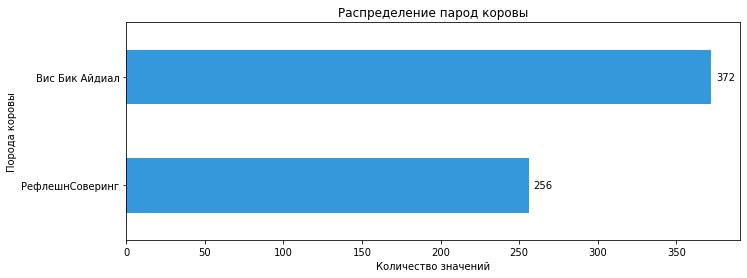

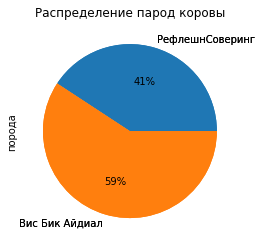

In [681]:
cat_info(main_data['порода'], 'Количество значений', 'Порода коровы', 'Распределение парод коровы')

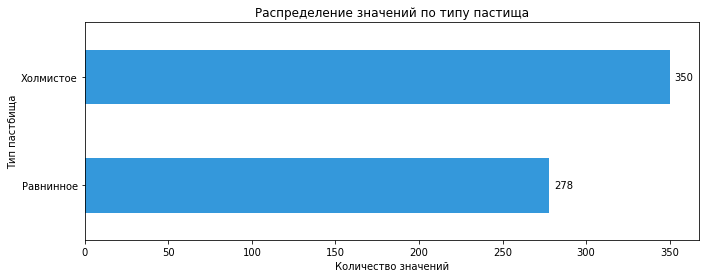

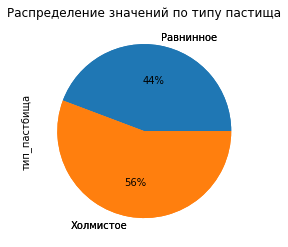

In [682]:
cat_info(main_data['тип_пастбища'],
         'Количество значений',
         'Тип пастбища',
         'Распределение значений по типу пастища')

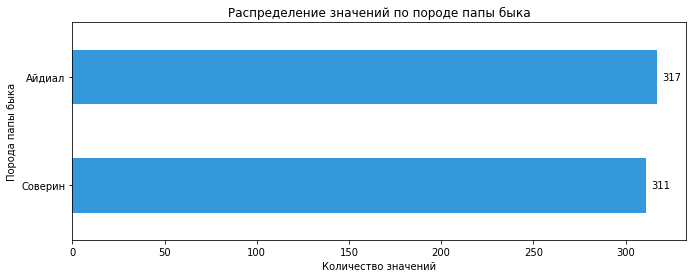

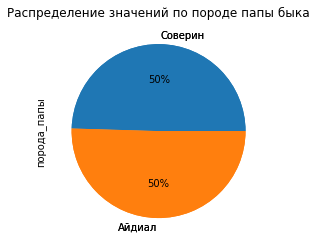

In [683]:
cat_info(main_data['порода_папы'],
         'Количество значений',
         'Порода папы быка',
         'Распределение значений по породе папы быка')

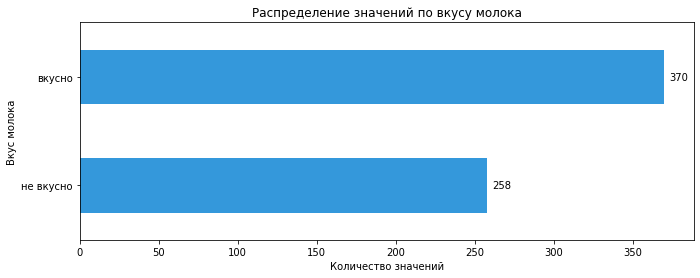

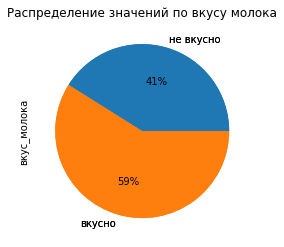

In [684]:
cat_info(main_data['вкус_молока'],
         'Количество значений',
         'Вкус молока',
         'Распределение значений по вкусу молока')

Невкусное молоко встречается чаще на 19 процентов.

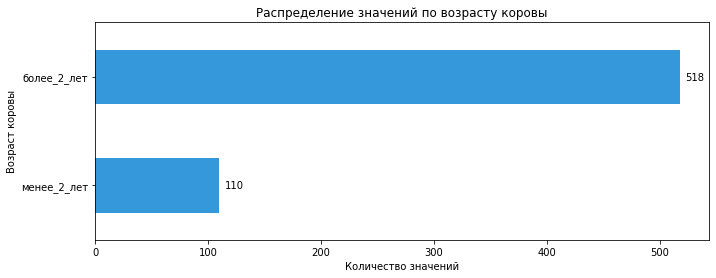

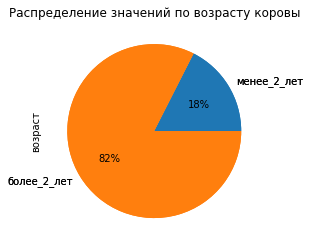

In [685]:
cat_info(main_data['возраст'],
         'Количество значений',
         'Возраст коровы',
         'Распределение значений по возрасту коровы')

### Исследование `cow_data`.

In [686]:
data_info(cow_data)

'Первые строки'

,порода,тип_пастбища,порода_папы,имя_папы,жирность,белок,возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.08,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.08,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.07,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.06,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.07,более_2_лет


'Описание данных'

,count,mean,std,min,25%,50%,75%,max
жирность,16.00,3.57,0.14,3.34,3.42,3.58,3.69,3.77
белок,16.00,3.07,0.01,3.05,3.06,3.07,3.08,3.08


'Базовая системная информация'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   порода        16 non-null     object 
 1   тип_пастбища  16 non-null     object 
 2   порода_папы   16 non-null     object 
 3   имя_папы      16 non-null     object 
 4   жирность      16 non-null     float64
 5   белок         16 non-null     float64
 6   возраст       16 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.0+ KB


None

Начнем с количественных данных.

**Столбец `порода`.**

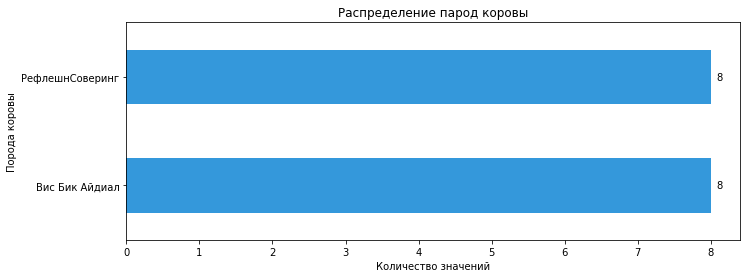

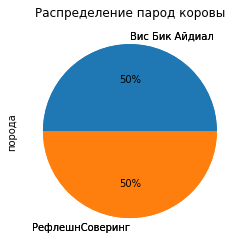

In [687]:
cat_info(cow_data['порода'], 'Количество значений', 'Порода коровы', 'Распределение парод коровы')

**Столбец `белок`.**

count   16.00
mean     3.07
std      0.01
min      3.05
25%      3.06
50%      3.07
75%      3.08
max      3.08
Name: белок, dtype: float64


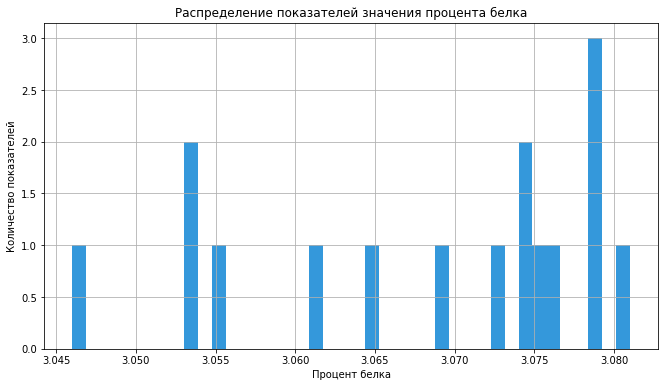

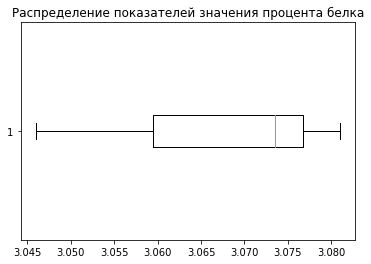

<Figure size 1080x432 with 0 Axes>

In [688]:
kol_info(cow_data['белок'],
         'Процент белка',
         'Количество показателей',
         'Распределение показателей значения процента белка', bins=40)

Перейдем к категориальным значениям.

**Столбец `тип_пастбища`.**

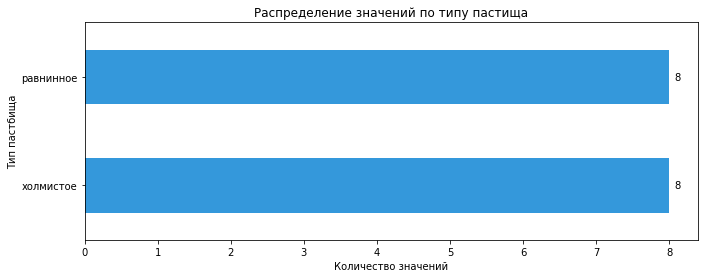

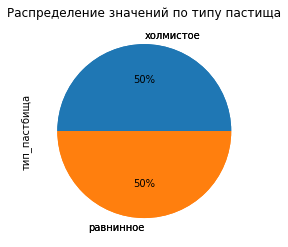

In [689]:
cat_info(cow_data['тип_пастбища'],
         'Количество значений',
         'Тип пастбища',
         'Распределение значений по типу пастища')

вывод

**Столбец `порода_папы`.**

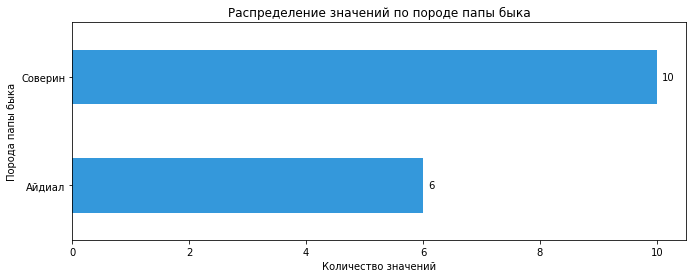

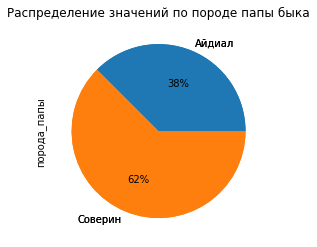

In [690]:
cat_info(cow_data['порода_папы'],
         'Количество значений',
         'Порода папы быка',
         'Распределение значений по породе папы быка')

вывод

**Стобец `имя_папы`.**

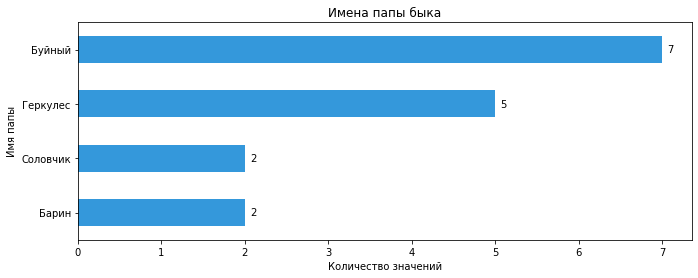

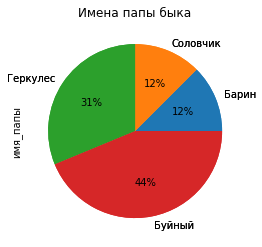

In [691]:
cat_info(cow_data['имя_папы'], 'Количество значений', 'Имя папы', 'Имена папы быка')

**Столбец `возраст`.**

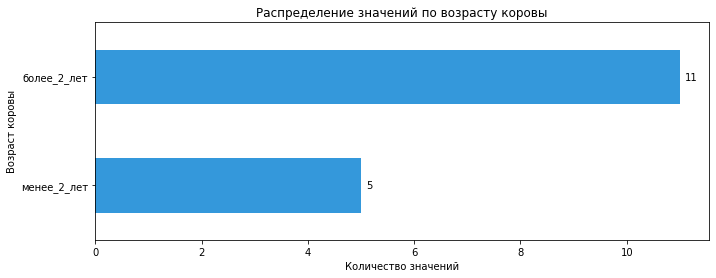

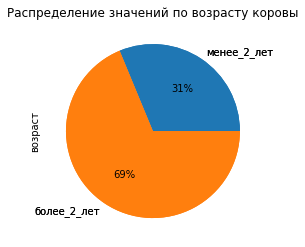

In [692]:
cat_info(cow_data['возраст'],
         'Количество значений',
         'Возраст коровы',
         'Распределение значений по возрасту коровы')

вывод

### Исследование `dad_data`

In [693]:
data_info(dad_data)

'Первые строки'

,id,имя_папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


'Описание данных'

,count,mean,std,min,25%,50%,75%,max
id,629.00,315.00,181.72,1.00,158.00,315.00,472.00,629.00


'Базовая системная информация'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   имя_папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


None

**Столбец `имя_папы`.**

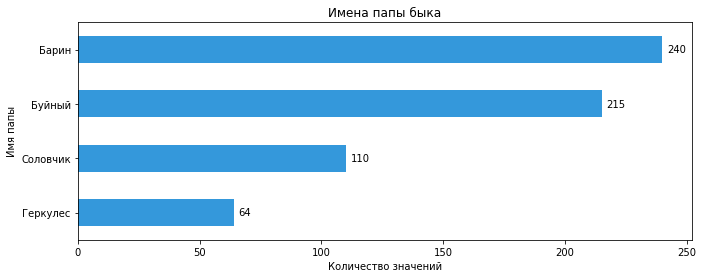

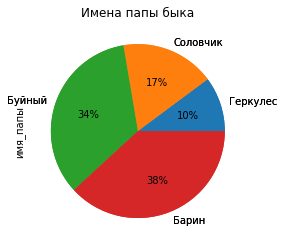

In [694]:
cat_info(dad_data['имя_папы'], 'Количество значений', 'Имя папы', 'Имена папы быка')

вывод

общий вывод

## Корреляционный анализ

In [695]:
main_data.corr()

,id,удой,эке,сырой_протеин,спо,жирность,белок
id,1.00,-0.01,-0.03,-0.04,-0.06,0.02,0.00
удой,-0.01,1.00,0.77,0.45,0.81,0.60,0.00
эке,-0.03,0.77,1.00,0.39,0.75,0.64,-0.01
сырой_протеин,-0.04,0.45,0.39,1.00,0.45,0.36,0.23
спо,-0.06,0.81,0.75,0.45,1.00,0.63,0.07
жирность,0.02,0.60,0.64,0.36,0.63,1.00,-0.03
белок,0.00,0.00,-0.01,0.23,0.07,-0.03,1.00


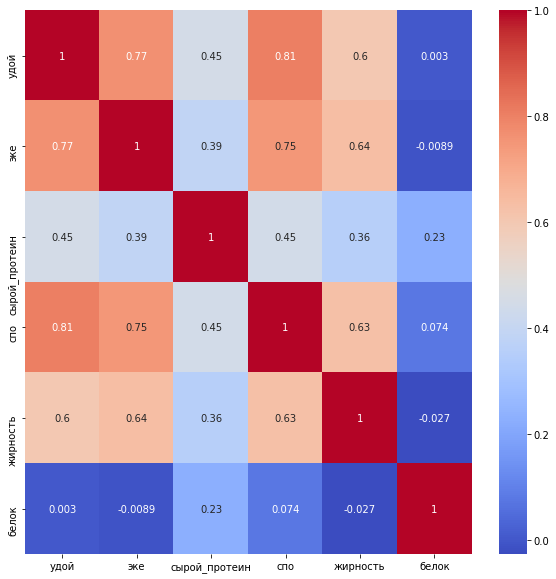

In [ ]:
plt.figure(figsize=(10, 10))
sns.heatmap(main_data.drop('id', axis=1).corr(), annot=True, cmap='coolwarm')
plt.show()

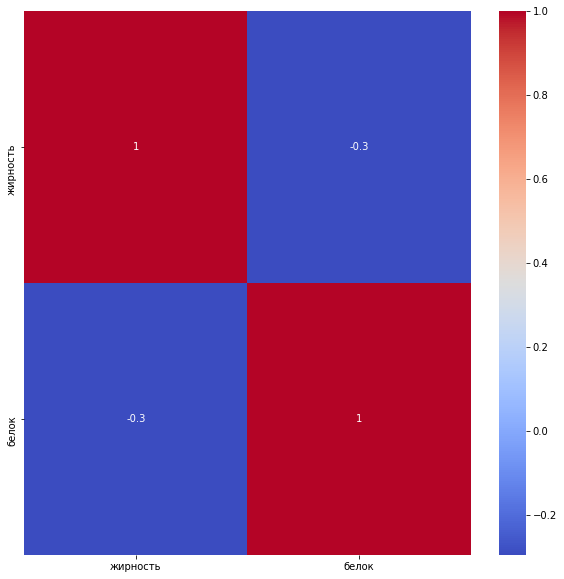

In [697]:
plt.figure(figsize=(10, 10))
sns.heatmap(cow_data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [698]:
main_data

,id,удой,эке,сырой_протеин,спо,порода,тип_пастбища,порода_папы,жирность,белок,вкус_молока,возраст
0,1,5863,14.20,1743,0.89,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.08,вкусно,более_2_лет
1,2,5529,12.80,2138,0.89,Вис Бик Айдиал,Равнинное,Соверин,3.54,3.08,вкусно,менее_2_лет
2,3,5810,14.00,1854,0.89,РефлешнСоверинг,Холмистое,Соверин,3.59,3.07,не вкусно,более_2_лет
3,4,5895,12.40,2012,0.89,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.08,не вкусно,более_2_лет
4,5,5302,12.80,1675,0.89,Вис Бик Айдиал,Равнинное,Соверин,3.73,3.07,вкусно,менее_2_лет
...,...,...,...,...,...,...,...,...,...,...,...,...
624,625,6812,15.40,1964,0.94,РефлешнСоверинг,Равнинное,Айдиал,3.74,3.08,не вкусно,более_2_лет
625,626,5513,12.90,1700,0.88,РефлешнСоверинг,Равнинное,Соверин,3.64,3.07,вкусно,менее_2_лет
626,627,5970,14.40,1837,0.88,РефлешнСоверинг,Холмистое,Соверин,3.64,3.08,не вкусно,более_2_лет
627,628,5746,13.80,1994,0.89,РефлешнСоверинг,Равнинное,Соверин,3.64,3.08,вкусно,более_2_лет


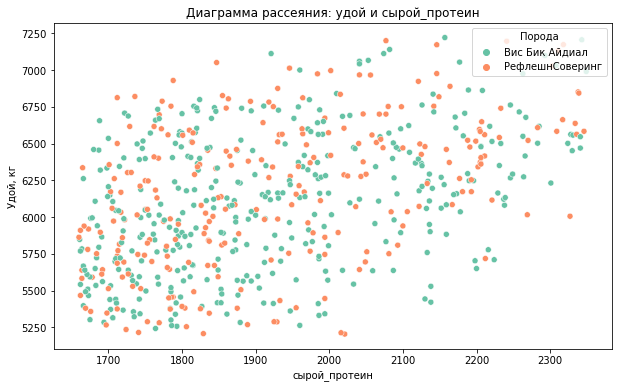

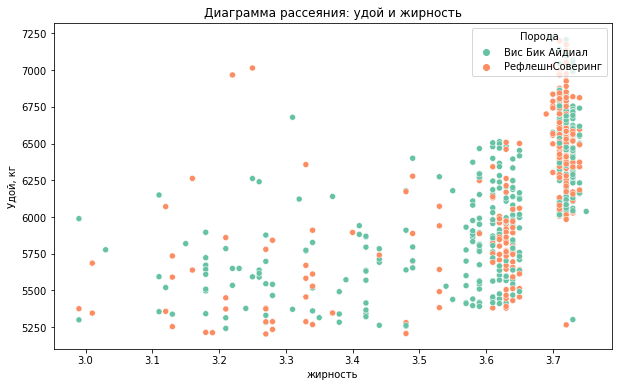

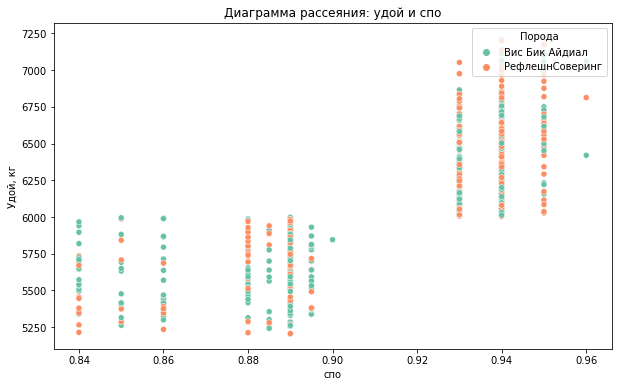

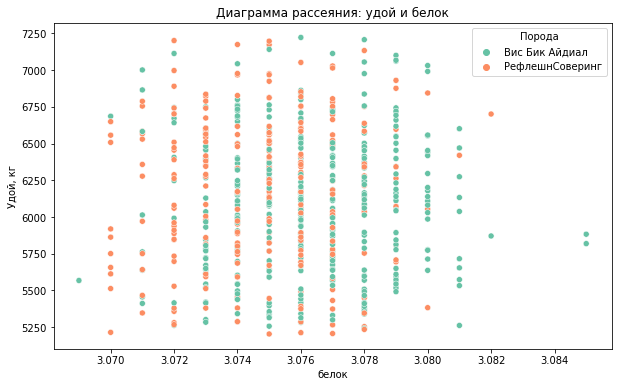

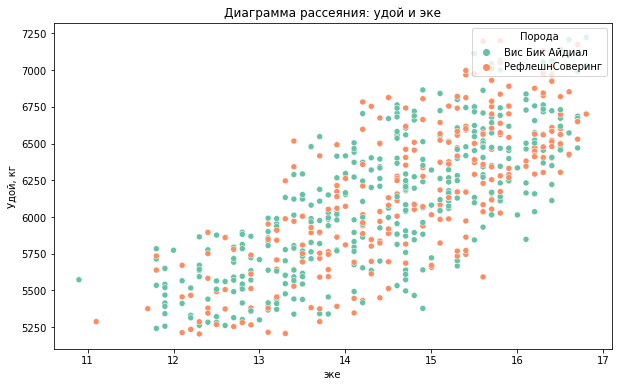

In [699]:
# Перебор всех количественных признаков для построения графиков
quantitative_features = ['сырой_протеин', 'жирность', 'спо', 'белок', 'эке']  # пример признаков

for feature in quantitative_features:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=main_data, x=feature, y='удой', hue='порода', palette='Set2')
    plt.title(f"Диаграмма рассеяния: удой и {feature}")
    plt.xlabel(feature)
    plt.ylabel('Удой, кг')
    plt.legend(title="Порода", loc='upper right')
    plt.show()

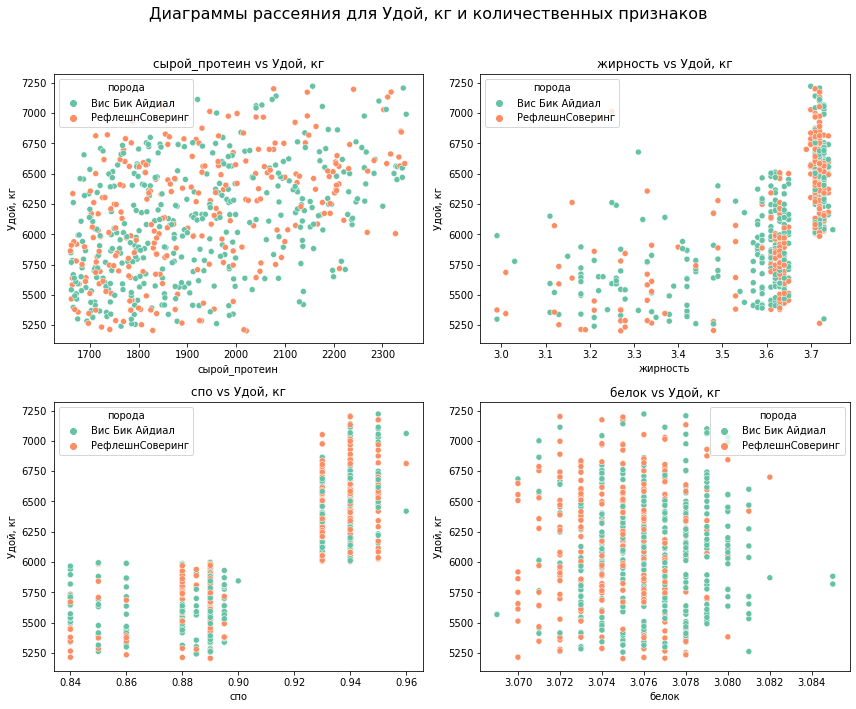

In [700]:

quantitative_features = ['сырой_протеин', 'жирность', 'спо', 'белок', 'эке']

# Создание сетки графиков
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
fig.suptitle("Диаграммы рассеяния для Удой, кг и количественных признаков", fontsize=16)

# Перебор признаков и построение scatter-плотов на каждом подграфике
for ax, feature in zip(axes.flatten(), quantitative_features):
    sns.scatterplot(data=main_data, x=feature, y='удой', hue='порода', ax=ax, palette='Set2')
    ax.set_title(f'{feature} vs Удой, кг')
    ax.set_xlabel(feature)
    ax.set_ylabel('Удой, кг')

# Оставляем пустые графики, если признаков меньше, чем ячеек в сетке
for ax in axes.flatten()[len(quantitative_features):]:
    ax.remove()

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Уменьшаем отступы
plt.show()


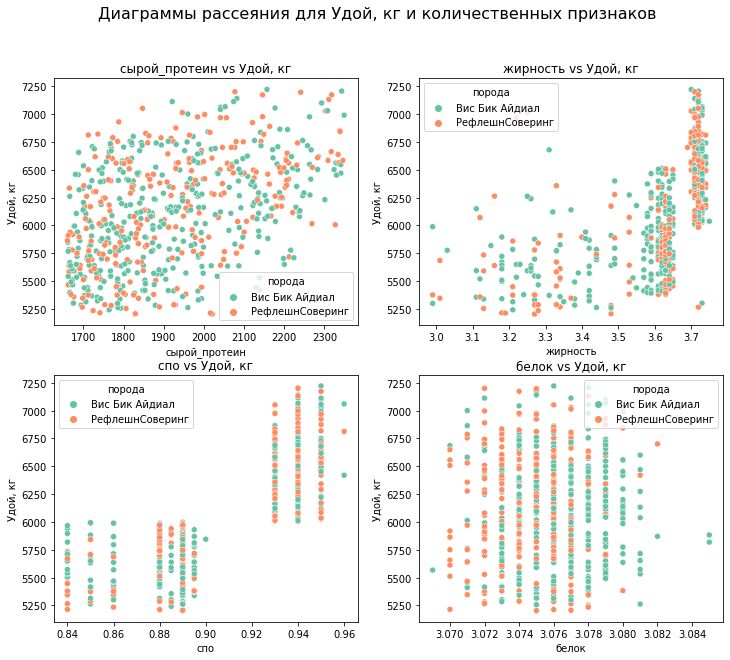

In [701]:

quantitative_features = ['сырой_протеин', 'жирность', 'спо', 'белок', 'эке']

# Создание сетки графиков
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
fig.suptitle("Диаграммы рассеяния для Удой, кг и количественных признаков", fontsize=16)

# Перебор признаков и построение scatter-плотов на каждом подграфике
for ax, feature in zip(axes.flatten(), quantitative_features):
    sns.scatterplot(data=main_data, x=feature, y='удой', hue='порода', ax=ax, palette='Set2')
    ax.set_title(f'{feature} vs Удой, кг')
    ax.set_xlabel(feature)
    ax.set_ylabel('Удой, кг')

# Оставляем пустые графики, если признаков меньше, чем ячеек в сетке
for ax in axes.flatten()[len(quantitative_features):]:
    ax.remove()

#plt.tight_layout(rect=[0, 0, 1, 0.96])  # Уменьшаем отступы
plt.show()


In [702]:
print(main_data[main_data['жирность'] >= 3.6]['порода'].value_counts())
main_data[main_data['жирность'] >= 1]['порода'].value_counts()

Вис Бик Айдиал     252
РефлешнСоверинг    205
Name: порода, dtype: int64


Вис Бик Айдиал     372
РефлешнСоверинг    256
Name: порода, dtype: int64

[Изучите взаимосвязь между признаками: рассчитайте коэффициенты корреляции между всеми признаками.
Постройте диаграммы рассеяния scatterplot для признака Удой, кг и всех количественных признаков с учётом значения категориальных признаков. Пример: диаграмма рассеяния для Удой, кг и Сырой протеин, г, цвет точек диаграммы отображает признак Порода. Учитывайте, что виды связи в подгруппах могут различаться — например, для разных пород.
Сделайте выводы о взаимосвязи признаков.
Какой тип взаимосвязи между целевым и входными признаками?
Есть ли нелинейные связи между целевым и входными признаками? Нужно ли вводить в модель дополнительные признаки, чтобы это учесть?
Наблюдается ли мультиколлинеарность между входными признаками?

## Обучение модели линейной регрессии

In [703]:
main_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 628 entries, 0 to 628
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             628 non-null    int64  
 1   удой           628 non-null    int64  
 2   эке            628 non-null    float64
 3   сырой_протеин  628 non-null    int64  
 4   спо            628 non-null    float64
 5   порода         628 non-null    object 
 6   тип_пастбища   628 non-null    object 
 7   порода_папы    628 non-null    object 
 8   жирность       628 non-null    float64
 9   белок          628 non-null    float64
 10  вкус_молока    628 non-null    object 
 11  возраст        628 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 63.8+ KB


In [ ]:
X = main_data.drop('удой',  axis=1)
y = main_data['удой']
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=RANDOM_STATE
)

num_col_names = [
    'эке',
    'сырой_протеин',
    'жирность',
    'спо',
    'белок'
]

cat_col_names = [
    'порода',
    'тип_пастбища',
    'порода_папы',
    'вкус_молока',
    'возраст'
]

In [705]:
scaler = StandardScaler()
encoder = OneHotEncoder(drop='first', sparse=False)

X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])

encoder_col_names = encoder.get_feature_names()

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

model_lr  = LinearRegression()
model_lr.fit(X_train, y_train)
predictions = model_lr.predict(X_test)
r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print("R2 LinearRegression =", r2)
print("RMSE LinearRegression =", rmse)

R2 LinearRegression = 0.7972246633383899
RMSE LinearRegression = 203.16976696674422


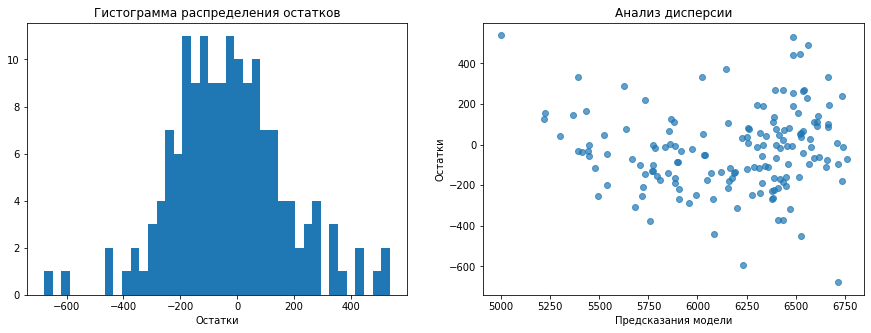

In [706]:
# проведем анализ остатков
# перед этим рассчитаем остатки
residuals = y_test - predictions

# постройте графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
axes[0].hist(residuals, bins=40)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(predictions, residuals, alpha=0.7)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
plt.show()

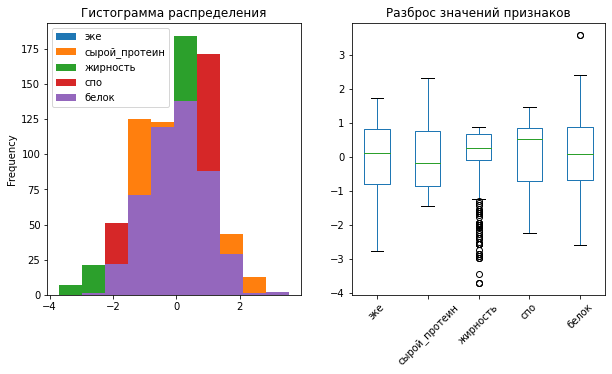

count   471.00
mean     -0.00
std       1.00
min      -3.71
25%      -0.10
50%       0.26
75%       0.68
max       0.86
Name: жирность, dtype: float64

In [707]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
X_train_scaled.plot(kind='hist', bins=10, ax=axes[0])
axes[0].set_title('Гистограмма распределения')
X_train_scaled.plot(kind='box', ax=axes[1], rot=45)
axes[1].set_title('Разброс значений признаков')
plt.show()

X_train_scaled['жирность'].describe()

In [708]:
import math

In [709]:
for feature_number, feature_name in enumerate(X_train.columns):
    weight = model_lr.coef_[feature_number]
    print(f"{feature_name:<20}: {weight:+.6f}")

x0_РефлешнСоверинг  : -20.636982
x1_Холмистое        : +73.774257
x2_Соверин          : -245.868922
x3_не вкусно        : +54.475173
x4_менее_2_лет      : -224.616055
эке                 : +147.646253
сырой_протеин       : +58.997135
жирность            : +27.366850
спо                 : +159.066218
белок               : -32.466707


In [710]:
spo_threshold = 0.92
main_data_add = main_data.copy()
main_data_add['спо_bin'] = (main_data['спо'] > spo_threshold)
main_data_add['квадрат_эке'] = main_data['эке'] ** 2

In [711]:
X = main_data_add.drop('удой',  axis=1)
y = main_data_add['удой']
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=RANDOM_STATE
)

num_col_names_2 = [
    'квадрат_эке',
    'сырой_протеин',
    'жирность',
    'белок'
    
]

cat_col_names_2 = [
    'порода',
    'тип_пастбища',
    'порода_папы',
    'вкус_молока',
    'спо_bin',
    'возраст'
]

In [712]:
scaler = StandardScaler()
encoder = OneHotEncoder(drop='first', sparse=False)

X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])

encoder_col_names = encoder.get_feature_names()

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

model_lr  = LinearRegression()
model_lr.fit(X_train, y_train)
predictions = model_lr.predict(X_test)
r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print("R2 LinearRegression =", r2)
print("RMSE LinearRegression =", rmse)

R2 LinearRegression = 0.7972246633383899
RMSE LinearRegression = 203.16976696674422


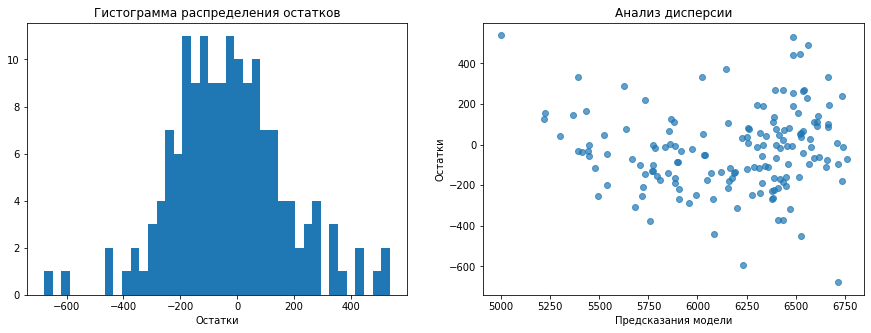

In [713]:
# проведем анализ остатков
# перед этим рассчитаем остатки
residuals = y_test - predictions

# постройте графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
axes[0].hist(residuals, bins=40)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(predictions, residuals, alpha=0.7)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
plt.show()

In [714]:
main_data_add.corr()

,id,удой,эке,сырой_протеин,спо,жирность,белок,спо_bin,квадрат_эке
id,1.00,-0.01,-0.03,-0.04,-0.06,0.02,0.00,-0.02,-0.03
удой,-0.01,1.00,0.77,0.45,0.81,0.60,0.00,0.83,0.77
эке,-0.03,0.77,1.00,0.39,0.75,0.64,-0.01,0.72,1.00
сырой_протеин,-0.04,0.45,0.39,1.00,0.45,0.36,0.23,0.42,0.39
спо,-0.06,0.81,0.75,0.45,1.00,0.63,0.07,0.92,0.75
жирность,0.02,0.60,0.64,0.36,0.63,1.00,-0.03,0.59,0.63
белок,0.00,0.00,-0.01,0.23,0.07,-0.03,1.00,0.05,-0.01
спо_bin,-0.02,0.83,0.72,0.42,0.92,0.59,0.05,1.00,0.71
квадрат_эке,-0.03,0.77,1.00,0.39,0.75,0.63,-0.01,0.71,1.00


In [715]:
main_data.corr()

,id,удой,эке,сырой_протеин,спо,жирность,белок
id,1.00,-0.01,-0.03,-0.04,-0.06,0.02,0.00
удой,-0.01,1.00,0.77,0.45,0.81,0.60,0.00
эке,-0.03,0.77,1.00,0.39,0.75,0.64,-0.01
сырой_протеин,-0.04,0.45,0.39,1.00,0.45,0.36,0.23
спо,-0.06,0.81,0.75,0.45,1.00,0.63,0.07
жирность,0.02,0.60,0.64,0.36,0.63,1.00,-0.03
белок,0.00,0.00,-0.01,0.23,0.07,-0.03,1.00


**разобраться!!!!**  
**разобраться!!!!**  
**разобраться!!!!**  
**разобраться!!!!**  
**разобраться!!!!**  
**разобраться!!!!**  
**разобраться!!!!**  
**разобраться!!!!**  
**разобраться!!!!**  
**разобраться!!!!**  
**разобраться!!!!**  
**разобраться!!!!**  
**разобраться!!!!**  
**разобраться!!!!**  
**разобраться!!!!**  
**разобраться!!!!**  

In [716]:
merged_data = main_data_add.merge(dad_data[['id', 'имя_папы']], on='id', how='left')

In [717]:
X = merged_data.drop('удой',  axis=1)
y = merged_data['удой']
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=RANDOM_STATE
)

num_col_names_3 = [
    'квадрат_эке',
    'сырой_протеин',
    'жирность',
    'белок'
    
]

cat_col_names_3 = [
    'порода',
    'тип_пастбища',
    'порода_папы',
    'вкус_молока',
    'спо_bin',
    'возраст',
    'имя_папы'
]

In [718]:
scaler = StandardScaler()
encoder = OneHotEncoder(drop='first', sparse=False)

X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])

encoder_col_names = encoder.get_feature_names()

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

model_lr  = LinearRegression()
model_lr.fit(X_train, y_train)
predictions = model_lr.predict(X_test)
r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print("R2 LinearRegression =", r2)
print("RMSE LinearRegression =", rmse)

R2 LinearRegression = 0.7972246633383899
RMSE LinearRegression = 203.16976696674422


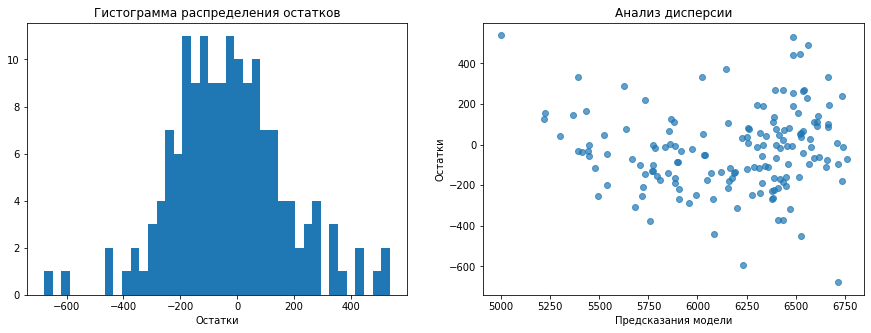

In [719]:
# проведем анализ остатков
# перед этим рассчитаем остатки
residuals = y_test - predictions

# постройте графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
axes[0].hist(residuals, bins=40)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(predictions, residuals, alpha=0.7)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
plt.show()

## Обучение модели логистической регрессии

In [720]:
main_data

,id,удой,эке,сырой_протеин,спо,порода,тип_пастбища,порода_папы,жирность,белок,вкус_молока,возраст
0,1,5863,14.20,1743,0.89,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.08,вкусно,более_2_лет
1,2,5529,12.80,2138,0.89,Вис Бик Айдиал,Равнинное,Соверин,3.54,3.08,вкусно,менее_2_лет
2,3,5810,14.00,1854,0.89,РефлешнСоверинг,Холмистое,Соверин,3.59,3.07,не вкусно,более_2_лет
3,4,5895,12.40,2012,0.89,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.08,не вкусно,более_2_лет
4,5,5302,12.80,1675,0.89,Вис Бик Айдиал,Равнинное,Соверин,3.73,3.07,вкусно,менее_2_лет
...,...,...,...,...,...,...,...,...,...,...,...,...
624,625,6812,15.40,1964,0.94,РефлешнСоверинг,Равнинное,Айдиал,3.74,3.08,не вкусно,более_2_лет
625,626,5513,12.90,1700,0.88,РефлешнСоверинг,Равнинное,Соверин,3.64,3.07,вкусно,менее_2_лет
626,627,5970,14.40,1837,0.88,РефлешнСоверинг,Холмистое,Соверин,3.64,3.08,не вкусно,более_2_лет
627,628,5746,13.80,1994,0.89,РефлешнСоверинг,Равнинное,Соверин,3.64,3.08,вкусно,более_2_лет


In [721]:
X = merged_data.drop('вкус_молока', axis=1)
y = merged_data['вкус_молока']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=RANDOM_STATE
)

In [722]:
X_train_ohe

,x0_РефлешнСоверинг,x1_Холмистое,x2_Соверин,x3_не вкусно,x4_менее_2_лет
0,1.00,1.00,1.00,0.00,0.00
1,1.00,1.00,1.00,0.00,1.00
2,0.00,0.00,0.00,1.00,0.00
3,0.00,1.00,0.00,0.00,0.00
4,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...
466,1.00,1.00,0.00,0.00,0.00
467,0.00,0.00,0.00,0.00,0.00
468,1.00,0.00,0.00,0.00,0.00
469,0.00,0.00,0.00,1.00,0.00


In [728]:
cat_col_names_3 = ['порода', 'тип_пастбища', 'порода_папы', 'возраст', 'спо_bin']
num_col_names_3 = ['жирность', 'белок', 'квадрат_эке', 'сырой_протеин']

In [729]:
#cat_col_names_3.remove('вкус_молока')

In [730]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names_3])
X_test_scaled = scaler.transform(X_test[num_col_names_3])

encoder = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col_names_3])
X_test_ohe = encoder.transform(X_test[cat_col_names_3])

encoder_col_names = encoder.get_feature_names()

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names_3)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names_3)

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_final = pd.concat([X_train_scaled, X_train_ohe], axis=1)
X_test_final = pd.concat([X_test_scaled, X_test_ohe], axis=1)

clf = LogisticRegression()
clf.fit(X_train_final, y_train)

y_pred = clf.predict(X_test_final)

In [731]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("Precision:", precision_score(y_test, y_pred, average='macro'))

Accuracy: 0.6242038216560509
Recall: 0.5928030303030303
Precision: 0.6293617998163452


In [ ]:
from sklearn.metrics import confusion_matrix

#строим матрицу ошибок
cm = confusion_matrix(y_test, y_pred)
cm

In [ ]:
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])

encoder_col_names = encoder.get_feature_names()

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

Подготовьте данные датасета ferma_main.csv и обучите на них модель LogisticRegression. 
Используйте в качестве целевого признак Вкус молока.
При необходимости преобразуйте имеющиеся или добавьте новые признаки.
Разбейте данные на тренировочную и тестовую выборки.
Кодируйте категориальные признаки с помощью OneHotEncoder.
Масштабируйте количественные признаки с помощью StandardScaler.
Обучите модель логистической регрессии на подготовленных данных.
Оцените качество модели на тестовой выборке: рассчитайте метрики accuracy, recall, precision.
Постройте матрицу ошибок.

## Итоговые выводы